In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!kaggle kernels output manvidhamija/notebook-2 -p /path/to/dest

Output file downloaded to /path/to/dest/flow_tensors/flow_0000.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0001.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0002.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0003.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0004.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0005.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0006.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0007.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0008.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0009.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0010.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0011.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0012.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0013.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0014.pt
Output fil

In [3]:
!kaggle kernels output manvidhamija/ids-18-2 -p /path/to/dest

Output file downloaded to /path/to/dest/Transformer_Pipeline/feature_columns.pkl
Output file downloaded to /path/to/dest/Transformer_Pipeline/label_encoder.pkl
Output file downloaded to /path/to/dest/Transformer_Pipeline/standard_scaler.pkl
Output file downloaded to /path/to/dest/best_transformer_model.pth
Output file downloaded to /path/to/dest/feature_columns.pkl
Output file downloaded to /path/to/dest/label_encoder.pkl
Output file downloaded to /path/to/dest/standard_scaler.pkl
Kernel log downloaded to /path/to/dest/ids-18-2.log 


In [4]:
# =================
# Cell 1 - Imports
# =================
import os
import gc
import random
import warnings
import joblib
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import (Dataset,DataLoader)
from torch.amp import (autocast,GradScaler)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)
warnings.filterwarnings("ignore")

In [5]:
# Cell 2 - Configuration
# ============================================================
# Input Directories
# ============================================================
INPUT_DIR = "/path/to/dest"
FLOW_DIR = os.path.join(INPUT_DIR,"flow_tensors")
FLOW_CATALOG = os.path.join(FLOW_DIR,"flow_catalog.csv")
# ============================================================
# Output Directory
# ============================================================
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR,exist_ok=True)
# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available()else "cpu")
# ------------------------------------------------------------
# Data Configuration
# ------------------------------------------------------------
DATA_CONFIG = {"batch_size": 256,"num_workers": 2}
# ------------------------------------------------------------
# Model Configuration
# ------------------------------------------------------------
MODEL_CONFIG = {"input_dim": 43,"num_classes": 14,"window_size": 32,"stride": 8,"d_model": 128,"nhead": 8,"num_layers": 4,"dim_feedforward": 256,"dropout": 0.1,"batch_size": 256}
# ------------------------------------------------------------
# Window Split Configuration
# ------------------------------------------------------------
SPLIT_CONFIG = {"train_ratio": 0.70,"val_ratio": 0.15,"test_ratio": 0.15,"guard_windows": MODEL_CONFIG["window_size"] // MODEL_CONFIG["stride"]}
# ------------------------------------------------------------
# Training Configuration
# ------------------------------------------------------------
TRAIN_CONFIG = {"epochs": 15,"learning_rate": 3e-4,"weight_decay": 1e-4,"patience": 5,"random_seed": 42}
CLASS_NAMES = {0: "Benign",1: "Brute Force-Web",2: "Brute Force-XSS",3: "HOIC",4: "LOIC-UDP",5: "LOIC-HTTP",6: "GoldenEye",7: "Hulk",8: "SlowHTTPTest",9: "Slowloris",10: "FTP-BruteForce",11: "Infilteration",12: "SQL Injection",13: "SSH-Bruteforce"}
# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
random.seed(TRAIN_CONFIG["random_seed"])
np.random.seed(TRAIN_CONFIG["random_seed"])
torch.manual_seed(TRAIN_CONFIG["random_seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TRAIN_CONFIG["random_seed"])
print("=" * 70)
print("Configuration Ready")
print("=" * 70)
print("Device :", DEVICE)
print("Batch Size :", DATA_CONFIG["batch_size"])

Configuration Ready
Device : cuda
Batch Size : 256


In [6]:
# ============================================================
# Cell 3 - Load Flow Tensor Dataset
# ============================================================
print("=" * 70)
print("Loading Flow Tensor Dataset...")
print("=" * 70)
# ------------------------------------------------------------
# Load Catalog
# ------------------------------------------------------------
flow_catalog = pd.read_csv(FLOW_CATALOG)
# ------------------------------------------------------------
# Verify Tensor Files
# ------------------------------------------------------------
missing_files = []
for tensor_file in flow_catalog["Tensor File"]:
    tensor_path = os.path.join(FLOW_DIR,tensor_file)
    if not os.path.exists(tensor_path):
        missing_files.append(tensor_file)
if len(missing_files) > 0:
    print("\nMissing Flow Tensor Files")
    for file in missing_files:
        print(file)
    raise FileNotFoundError("Some flow tensor files are missing.")
# ------------------------------------------------------------
# Dataset Summary
# ------------------------------------------------------------
print()
print("=" * 70)
print("Dataset Summary")
print("=" * 70)
print(f"Flow Tensor Files : {len(flow_catalog)}")
print(f"Total Flows       : {flow_catalog['Flows'].sum():,}")
print(f"Input Features    : {flow_catalog['Features'].iloc[0]}")
print(f"Number of Classes : {MODEL_CONFIG['num_classes']}")
print()
# ------------------------------------------------------------
# Preview Catalog
# ------------------------------------------------------------
print("=" * 70)
print("Catalog Preview")
print("=" * 70)
display(flow_catalog.head())
# ------------------------------------------------------------
# Inspect Sample Tensor
# ------------------------------------------------------------
sample_path = os.path.join(FLOW_DIR,flow_catalog.iloc[0]["Tensor File"])
sample = torch.load(sample_path)
print()
print("=" * 70)
print("Sample Tensor")
print("=" * 70)
print("Tensor File :", flow_catalog.iloc[0]["Tensor File"])
print("X Shape     :", tuple(sample["X"].shape))
print("y Shape     :", tuple(sample["y"].shape))
print()
print("Metadata")
for key, value in sample["metadata"].items():
    print(f"{key:<15}: {value}")
# ------------------------------------------------------------
# Model Input Dimension
# ------------------------------------------------------------
MODEL_CONFIG["input_dim"] = sample["X"].shape[1]
# ------------------------------------------------------------
# Expected Window Count
# ------------------------------------------------------------
total_windows = 0
for flows in flow_catalog["Flows"]:
    windows = ((flows - MODEL_CONFIG["window_size"])// MODEL_CONFIG["stride"]) + 1
    total_windows += max(0, windows)
print()
print("=" * 70)
print("Expected Windows")
print("=" * 70)
print(f"Approximate Windows : {total_windows:,}")
print()
print("=" * 70)
print(f"Model Input Dimension : {MODEL_CONFIG['input_dim']}")
print("=" * 70)
del sample
gc.collect()

Loading Flow Tensor Dataset...

Dataset Summary
Flow Tensor Files : 41
Total Flows       : 15,730,957
Input Features    : 43
Number of Classes : 14

Catalog Preview


,Tensor File,Source File,Date,Flows,Features,Classes
0,flow_0000.pt,clean_chunk_1.csv,2018-03-02,498028,43,Benign
1,flow_0001.pt,clean_chunk_10.csv,2018-02-20,500000,43,Benign
2,flow_0002.pt,clean_chunk_11.csv,2018-02-20,500000,43,Benign
3,flow_0003.pt,clean_chunk_12.csv,2018-02-20,500000,43,Benign
4,flow_0004.pt,clean_chunk_13.csv,2018-02-20,500000,43,Benign



Sample Tensor
Tensor File : flow_0000.pt
X Shape     : (498028, 43)
y Shape     : (498028,)

Metadata
file           : clean_chunk_1.csv
date           : 2018-03-02
num_flows      : 498028
num_features   : 43
classes        : ['Benign']

Expected Windows
Approximate Windows : 1,966,237

Model Input Dimension : 43


61

In [7]:
# ============================================================
# Cell 4 - Analyze Flow Tensors
# ============================================================
from collections import Counter
print("=" * 70)
print("Analyzing Flow Tensors...")
print("=" * 70)
tensor_analysis = []
overall_counter = Counter()
for _, row in tqdm(flow_catalog.iterrows(),total=len(flow_catalog)):
    tensor_path = os.path.join(FLOW_DIR,row["Tensor File"])
    data = torch.load(tensor_path,map_location="cpu")
    y = data["y"].numpy()
    class_counts = Counter(y)
    overall_counter.update(class_counts)
    tensor_analysis.append({"Tensor File": row["Tensor File"],"Date": row["Date"],"Flows": len(y),"Num Classes": len(class_counts),"Class IDs": sorted(class_counts.keys()),"Class Counts": dict(class_counts)})
    del data
    gc.collect()
tensor_analysis = pd.DataFrame(tensor_analysis)
print()
print("=" * 70)
print("Tensor Analysis Summary")
print("=" * 70)
display(tensor_analysis[["Tensor File","Date","Flows","Num Classes","Class IDs"]])
print()
print("=" * 70)
print("Overall Class Distribution")
print("=" * 70)
for cls, count in sorted(overall_counter.items()):
    print(f"Class {cls:2d} " f"({CLASS_NAMES[cls]:<18}) : " f"{count:,}")
print()
print("=" * 70)
print("Attack Tensor Summary")
print("=" * 70)
attack_tensors = tensor_analysis[tensor_analysis["Num Classes"] > 1]
print(f"Attack Tensors : {len(attack_tensors)}")
print(f"Benign Tensors : {len(tensor_analysis) - len(attack_tensors)}")
display(attack_tensors[["Tensor File","Date","Class IDs"]])

Analyzing Flow Tensors...


  0%|          | 0/41 [00:00<?, ?it/s]


Tensor Analysis Summary


,Tensor File,Date,Flows,Num Classes,Class IDs
0,flow_0000.pt,2018-03-02,498028,1,[0]
1,flow_0001.pt,2018-02-20,500000,1,[0]
2,flow_0002.pt,2018-02-20,500000,1,[0]
3,flow_0003.pt,2018-02-20,500000,1,[0]
4,flow_0004.pt,2018-02-20,500000,1,[0]
5,flow_0005.pt,2018-02-20,500000,1,[0]
6,flow_0006.pt,2018-02-20,500000,1,[0]
7,flow_0007.pt,2018-02-20,500000,1,[0]
8,flow_0008.pt,2018-02-20,500000,1,[0]
9,flow_0009.pt,2018-02-20,500000,1,[0]



Overall Class Distribution
Class  0 (Benign            ) : 13,268,913
Class  1 (Brute Force-Web   ) : 611
Class  2 (Brute Force-XSS   ) : 230
Class  3 (HOIC              ) : 686,012
Class  4 (LOIC-UDP          ) : 1,730
Class  5 (LOIC-HTTP         ) : 576,191
Class  6 (GoldenEye         ) : 41,508
Class  7 (Hulk              ) : 461,912
Class  8 (SlowHTTPTest      ) : 139,890
Class  9 (Slowloris         ) : 10,990
Class 10 (FTP-BruteForce    ) : 193,360
Class 11 (Infilteration     ) : 161,934
Class 12 (SQL Injection     ) : 87
Class 13 (SSH-Bruteforce    ) : 187,589

Attack Tensor Summary
Attack Tensors : 14
Benign Tensors : 27


,Tensor File,Date,Class IDs
11,flow_0011.pt,2018-02-16,"[0, 7, 8]"
15,flow_0015.pt,2018-02-15,"[0, 6, 9]"
17,flow_0017.pt,2018-03-01,"[0, 11]"
20,flow_0020.pt,2018-02-22,"[0, 1, 2, 12]"
23,flow_0029.pt,2018-02-14,"[0, 10, 13]"
27,flow_0033.pt,2018-02-21,"[0, 3, 4]"
28,flow_0034.pt,2018-02-16,"[0, 7]"
29,flow_0035.pt,2018-02-21,"[0, 3]"
30,flow_0036.pt,2018-02-21,"[0, 3]"
32,flow_0038.pt,2018-02-28,"[0, 11]"


In [8]:
# ============================================================
# Cell 5 - Temporal Attack Analyzer
# ============================================================
from collections import defaultdict
print("=" * 70)
print("Analyzing Temporal Attack Distribution...")
print("=" * 70)
attack_analysis = []
# ------------------------------------------------------------
# Analyze Only Mixed Tensors
# ------------------------------------------------------------
mixed_tensors = tensor_analysis[tensor_analysis["Num Classes"] > 1].reset_index(drop=True)
for _, row in tqdm(mixed_tensors.iterrows(),total=len(mixed_tensors)):
    tensor_path = os.path.join(FLOW_DIR,row["Tensor File"])
    data = torch.load(tensor_path,map_location="cpu")
    y = data["y"].numpy()
    total_flows = len(y)
    classes = np.unique(y)
    # --------------------------------------------------------
    # Analyze Each Attack Class
    # --------------------------------------------------------
    for cls in classes:
        if cls == 0:
            continue
        indices = np.where(y == cls)[0]
        start = indices[0]
        end = indices[-1]
        # ----------------------------------------------------
        # Count Attack Regions
        # ----------------------------------------------------
        regions = 1
        for i in range(1, len(indices)):
            if indices[i] != indices[i-1] + 1:
                regions += 1
        attack_analysis.append({"Tensor File": row["Tensor File"],"Date": row["Date"],"Class ID": int(cls),"Count": len(indices),"Length": int(end - start + 1),"Start Index": int(start),"End Index": int(end),"Start %": start / total_flows,"End %": end / total_flows,"Regions": regions})
    del data
    gc.collect()
attack_analysis = pd.DataFrame(attack_analysis)
# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------
print()
print("=" * 70)
print("Temporal Attack Summary")
print("=" * 70)
display(attack_analysis)
print()
print("=" * 70)
print("Attack Coverage")
print("=" * 70)
summary = attack_analysis.groupby("Class ID").agg(Tensors=("Tensor File", "count"),Total_Flows=("Count", "sum"))
display(summary)

Analyzing Temporal Attack Distribution...


  0%|          | 0/14 [00:00<?, ?it/s]


Temporal Attack Summary


,Tensor File,Date,Class ID,Count,Length,Start Index,End Index,Start %,End %,Regions
0,flow_0011.pt,2018-02-16,7,190787,359722,43,359764,0.000095,0.796952,4402
1,flow_0011.pt,2018-02-16,8,91434,91468,359864,451331,0.797173,0.999792,35
2,flow_0015.pt,2018-02-15,6,41508,42242,12116,54357,0.162845,0.730585,200
3,flow_0015.pt,2018-02-15,9,10990,14010,56939,70948,0.765289,0.953577,987
4,flow_0017.pt,2018-03-01,11,93063,248046,32528,280573,0.098242,0.847397,6738
5,flow_0020.pt,2018-02-22,1,249,4579,17527,22105,0.678631,0.855887,119
6,flow_0020.pt,2018-02-22,2,79,1955,3226,5180,0.124908,0.200565,48
7,flow_0020.pt,2018-02-22,12,34,18355,3270,21624,0.126612,0.837263,26
8,flow_0029.pt,2018-02-14,10,193360,223081,244382,467462,0.512066,0.979497,8777
9,flow_0029.pt,2018-02-14,13,187589,197597,7418,205014,0.015543,0.429576,4150



Attack Coverage


,Tensors,Total_Flows
Class ID,,
1,2,611
2,2,230
3,3,686012
4,1,1730
5,2,576191
6,1,41508
7,3,461912
8,2,139890
9,1,10990


In [9]:
print("=" * 70)
print("Generating Window Manifest...")
print("=" * 70)
window_manifest = []
WINDOW_SIZE = MODEL_CONFIG["window_size"]
STRIDE = MODEL_CONFIG["stride"]
for _, row in tqdm(flow_catalog.iterrows(),total=len(flow_catalog)):
    tensor_file = row["Tensor File"]
    tensor_path = os.path.join(FLOW_DIR,tensor_file)
    data = torch.load(tensor_path,map_location="cpu")
    X = data["X"]
    y = data["y"].numpy()
    n = len(y)
    # ---------------------------------------------
    # Generate Sliding Windows
    # ---------------------------------------------
    for start in range(0,n - WINDOW_SIZE + 1,STRIDE):
        end = start + WINDOW_SIZE
        # Last-flow labeling
        label = int(y[end - 1])
        window_manifest.append({"Tensor File": tensor_file,"Date": row["Date"],"Window Start": start,"Window End": end,"Label": label,"Class": CLASS_NAMES[label]})
    del data
    gc.collect()
window_manifest = pd.DataFrame(window_manifest)
print()
print("=" * 70)
print("Window Manifest Summary")
print("=" * 70)
print(f"Total Windows : {len(window_manifest):,}")
print()
display(window_manifest.head())
print()
print("=" * 70)
print("Windows per Class")
print("=" * 70)
window_distribution = (window_manifest.groupby(["Label", "Class"]).size().reset_index(name="Windows"))
display(window_distribution)
# ---------------------------------------------
# Save
# ---------------------------------------------
window_manifest_path = os.path.join(OUTPUT_DIR,"window_manifest.csv")
window_manifest.to_csv(window_manifest_path,index=False)
print()
print("=" * 70)
print("Manifest Saved")
print("=" * 70)
print(window_manifest_path)

Generating Window Manifest...


  0%|          | 0/41 [00:00<?, ?it/s]


Window Manifest Summary
Total Windows : 1,966,237



,Tensor File,Date,Window Start,Window End,Label,Class
0,flow_0000.pt,2018-03-02,0,32,0,Benign
1,flow_0000.pt,2018-03-02,8,40,0,Benign
2,flow_0000.pt,2018-03-02,16,48,0,Benign
3,flow_0000.pt,2018-03-02,24,56,0,Benign
4,flow_0000.pt,2018-03-02,32,64,0,Benign



Windows per Class


,Label,Class,Windows
0,0,Benign,1658701
1,1,Brute Force-Web,68
2,2,Brute Force-XSS,26
3,3,HOIC,85622
4,4,LOIC-UDP,228
5,5,LOIC-HTTP,72006
6,6,GoldenEye,5191
7,7,Hulk,57663
8,8,SlowHTTPTest,17484
9,9,Slowloris,1359



Manifest Saved
/kaggle/working/window_manifest.csv


In [10]:
# ============================================================
# Cell 7 - Adaptive Temporal Window Split
# ============================================================
print("=" * 70)
print("Building Adaptive Temporal Window Split...")
print("=" * 70)
window_manifest = window_manifest.copy()
window_manifest["Split"] = "Guard"
split_summary = []
# ------------------------------------------------------------
# Split each class independently
# ------------------------------------------------------------
for cls in sorted(window_manifest["Label"].unique()):
    class_windows = (window_manifest[window_manifest["Label"] == cls].sort_values(["Date", "Tensor File", "Window Start"]).copy())
    n = len(class_windows)
    # --------------------------------------------------------
    # Adaptive Strategy
    # --------------------------------------------------------
    if n >= 100:
        strategy = "70/15/15"
        train = int(0.70 * n)
        val = int(0.15 * n)
        test = n - train - val
        guard = SPLIT_CONFIG["guard_windows"]
    elif n >= 30:
        strategy = "80/10/10"
        train = int(0.80 * n)
        val = int(0.10 * n)
        test = n - train - val
        guard = 0
    elif n >= 20:
        strategy = "15/6/Remaining"
        train = 15
        val = 6
        test = n - train - val
        guard = 0
    elif n >= 10:
        strategy = "8/4/Remaining"
        train = 8
        val = 4
        test = n - train - val
        guard = 0
    elif n >= 5:
        strategy = "2/2/1"
        train = 2
        val = 2
        test = n - 4
        guard = 0
    else:
        strategy = "Train Only"
        train = n
        val = 0
        test = 0
        guard = 0
    # --------------------------------------------------------
    # Assign Splits
    # --------------------------------------------------------
    indices = class_windows.index.to_list()
    train_end = train
    val_start = min(train_end + guard, n)
    val_end = min(val_start + val, n)
    test_start = min(val_end + guard, n)
    train_idx = indices[:train_end]
    val_idx = indices[val_start:val_end]
    test_idx = indices[test_start:]
    window_manifest.loc[train_idx, "Split"] = "Train"
    window_manifest.loc[val_idx, "Split"] = "Validation"
    window_manifest.loc[test_idx, "Split"] = "Test"
    split_summary.append({"Class ID": cls,"Class": CLASS_NAMES[cls],"Windows": n,"Train": len(train_idx),"Validation": len(val_idx),"Test": len(test_idx),"Strategy": strategy})
# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
split_summary = pd.DataFrame(split_summary)
print()
print("=" * 70)
print("Adaptive Split Summary")
print("=" * 70)
display(split_summary)
print()
print("=" * 70)
print("Overall Split Counts")
print("=" * 70)
print(window_manifest["Split"].value_counts())
print()
print("=" * 70)
print("Windows per Split")
print("=" * 70)
print(window_manifest.groupby("Split").size())
# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
split_manifest_path = os.path.join(OUTPUT_DIR,"window_split_manifest.csv")
window_manifest.to_csv(split_manifest_path,index=False)
print()
print("=" * 70)
print("Split Manifest Saved")
print("=" * 70)
print(split_manifest_path)

Building Adaptive Temporal Window Split...

Adaptive Split Summary


,Class ID,Class,Windows,Train,Validation,Test,Strategy
0,0,Benign,1658701,1161090,248805,248798,70/15/15
1,1,Brute Force-Web,68,54,6,8,80/10/10
2,2,Brute Force-XSS,26,15,6,5,15/6/Remaining
3,3,HOIC,85622,59935,12843,12836,70/15/15
4,4,LOIC-UDP,228,159,34,27,70/15/15
5,5,LOIC-HTTP,72006,50404,10800,10794,70/15/15
6,6,GoldenEye,5191,3633,778,772,70/15/15
7,7,Hulk,57663,40364,8649,8642,70/15/15
8,8,SlowHTTPTest,17484,12238,2622,2616,70/15/15
9,9,Slowloris,1359,951,203,197,70/15/15



Overall Split Counts
Split
Train         1376362
Validation     294930
Test           294857
Guard              88
Name: count, dtype: int64

Windows per Split
Split
Guard              88
Test           294857
Train         1376362
Validation     294930
dtype: int64

Split Manifest Saved
/kaggle/working/window_split_manifest.csv


In [11]:
print("=" * 70)
print("Building Window Datasets...")
print("=" * 70)
# ------------------------------------------------------------
# Remove Guard Windows
# ------------------------------------------------------------
window_manifest = (window_manifest[window_manifest["Split"] != "Guard"].reset_index(drop=True))
# ------------------------------------------------------------
# Dataset Class
# ------------------------------------------------------------
class WindowDataset(Dataset):
    def __init__(self, manifest):
        self.manifest = (manifest.reset_index(drop=True).to_dict("records"))
        # Cache loaded tensors
        self.cache = {}
    def __len__(self):
        return len(self.manifest)
    def __getitem__(self, idx):
        row = self.manifest[idx]
        tensor_file = row["Tensor File"]
        if tensor_file not in self.cache:
            tensor_path = os.path.join(FLOW_DIR,tensor_file)
            self.cache[tensor_file] = torch.load(tensor_path,map_location="cpu")
        data = self.cache[tensor_file]
        start = int(row["Window Start"])
        end = int(row["Window End"])
        X = data["X"][start:end].float()
        y = torch.tensor(int(row["Label"]),dtype=torch.long)
        return X, y
# ------------------------------------------------------------
# Split Manifests
# ------------------------------------------------------------
train_manifest = (window_manifest[window_manifest["Split"] == "Train"].reset_index(drop=True))
val_manifest = (window_manifest[window_manifest["Split"] == "Validation"].reset_index(drop=True))
test_manifest = (window_manifest[window_manifest["Split"] == "Test"].reset_index(drop=True))
# ------------------------------------------------------------
# Build Datasets
# ------------------------------------------------------------
train_dataset = WindowDataset(train_manifest)
val_dataset = WindowDataset(val_manifest)
test_dataset = WindowDataset(test_manifest)
# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print()
print("=" * 70)
print("Dataset Summary")
print("=" * 70)
print(f"Train Windows      : {len(train_dataset):,}")
print(f"Validation Windows : {len(val_dataset):,}")
print(f"Test Windows       : {len(test_dataset):,}")
print()
print("=" * 70)
print("Sample Inspection")
print("=" * 70)
X, y = train_dataset[0]
print("X Shape :", tuple(X.shape))
print("y       :", y.item())
print("X dtype :", X.dtype)
print("y dtype :", y.dtype)

Building Window Datasets...

Dataset Summary
Train Windows      : 1,376,362
Validation Windows : 294,930
Test Windows       : 294,857

Sample Inspection
X Shape : (32, 43)
y       : 0
X dtype : torch.float32
y dtype : torch.int64


In [12]:
print("=" * 70)
print("Verifying Dataset Class Distribution...")
print("=" * 70)

for name, manifest in [
    ("Train", train_manifest),
    ("Validation", val_manifest),
    ("Test", test_manifest),
]:

    print(f"\n{name}")

    dist = (
        manifest
        .groupby(["Label", "Class"])
        .size()
        .reset_index(name="Windows")
        .sort_values("Label")
    )

    display(dist)

Verifying Dataset Class Distribution...

Train


,Label,Class,Windows
0,0,Benign,1161090
1,1,Brute Force-Web,54
2,2,Brute Force-XSS,15
3,3,HOIC,59935
4,4,LOIC-UDP,159
5,5,LOIC-HTTP,50404
6,6,GoldenEye,3633
7,7,Hulk,40364
8,8,SlowHTTPTest,12238
9,9,Slowloris,951



Validation


,Label,Class,Windows
0,0,Benign,248805
1,1,Brute Force-Web,6
2,2,Brute Force-XSS,6
3,3,HOIC,12843
4,4,LOIC-UDP,34
5,5,LOIC-HTTP,10800
6,6,GoldenEye,778
7,7,Hulk,8649
8,8,SlowHTTPTest,2622
9,9,Slowloris,203



Test


,Label,Class,Windows
0,0,Benign,248798
1,1,Brute Force-Web,8
2,2,Brute Force-XSS,5
3,3,HOIC,12836
4,4,LOIC-UDP,27
5,5,LOIC-HTTP,10794
6,6,GoldenEye,772
7,7,Hulk,8642
8,8,SlowHTTPTest,2616
9,9,Slowloris,197


In [16]:
num_workers=2

In [17]:
# ============================================================
# Cell 9 - Build DataLoaders
# ============================================================
print("=" * 70)
print("Building DataLoaders...")
print("=" * 70)
# ------------------------------------------------------------
# Train DataLoader
# ------------------------------------------------------------
train_loader = DataLoader(train_dataset,batch_size=MODEL_CONFIG["batch_size"],shuffle=True,num_workers=2,pin_memory=torch.cuda.is_available(),persistent_workers=(num_workers > 0))
# ------------------------------------------------------------
# Validation DataLoader
# ------------------------------------------------------------
val_loader = DataLoader(val_dataset,batch_size=MODEL_CONFIG["batch_size"],shuffle=False,num_workers=2,pin_memory=torch.cuda.is_available(),persistent_workers=(num_workers > 0))
# ------------------------------------------------------------
# Test DataLoader
# ------------------------------------------------------------
test_loader = DataLoader(test_dataset,batch_size=MODEL_CONFIG["batch_size"],shuffle=False,num_workers=2,pin_memory=torch.cuda.is_available(),persistent_workers=(num_workers > 0))
# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print()
print("=" * 70)
print("DataLoader Summary")
print("=" * 70)
print(f"Train Batches      : {len(train_loader):,}")
print(f"Validation Batches : {len(val_loader):,}")
print(f"Test Batches       : {len(test_loader):,}")
print()
print("=" * 70)
print("Batch Inspection")
print("=" * 70)
X_batch, y_batch = next(iter(train_loader))
print("Input Shape :", tuple(X_batch.shape))
print("Label Shape :", tuple(y_batch.shape))
print()
print("Input dtype :", X_batch.dtype)
print("Label dtype :", y_batch.dtype)
print()
print("Unique Labels in Batch")
print(torch.unique(y_batch))

Building DataLoaders...

DataLoader Summary
Train Batches      : 5,377
Validation Batches : 1,153
Test Batches       : 1,152

Batch Inspection
Input Shape : (256, 32, 43)
Label Shape : (256,)

Input dtype : torch.float32
Label dtype : torch.int64

Unique Labels in Batch
tensor([ 0,  3,  5,  7,  8, 11, 13])


In [18]:
X, _ = next(iter(train_loader))

print("Mean :", X.mean())
print("Std  :", X.std())
print("Min  :", X.min())
print("Max  :", X.max())

Mean : tensor(-0.0150)
Std  : tensor(0.9097)
Min  : tensor(-3.7141)
Max  : tensor(38.1443)


In [19]:
# ============================================================
# Cell 10 - Compute Class Weights
# ============================================================
print("=" * 70)
print("Computing Class Weights...")
print("=" * 70)
# ------------------------------------------------------------
# Training Distribution
# ------------------------------------------------------------
train_distribution = (train_manifest.groupby(["Label", "Class"]).size().reset_index(name="Windows").sort_values("Label"))
display(train_distribution)
# ------------------------------------------------------------
# Effective Number of Samples
# Cui et al., CVPR 2019
# ------------------------------------------------------------
beta = 0.9999
class_weights = np.zeros(MODEL_CONFIG["num_classes"],dtype=np.float32)
for _, row in train_distribution.iterrows():
    cls = int(row["Label"])
    n = int(row["Windows"])
    effective_num = 1.0 - np.power(beta, n)
    class_weights[cls] = ((1.0 - beta) / effective_num)
# ------------------------------------------------------------
# Normalize
# ------------------------------------------------------------
class_weights = (class_weights /class_weights.mean())
class_weights = torch.tensor(class_weights,dtype=torch.float32)
# class_weights = torch.clamp(
#     class_weights,
#     max=10.0
# )
# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
weights_df = train_distribution.copy()
weights_df["Weight"] = (class_weights.numpy())
print()
print("=" * 70)
print("Class Weights")
print("=" * 70)
display(weights_df)
print()
print("=" * 70)
print("Statistics")
print("=" * 70)
print(f"Minimum Weight : {class_weights.min():.4f}")
print(f"Maximum Weight : {class_weights.max():.4f}")
print(f"Mean Weight    : {class_weights.mean():.4f}")
# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = class_weights.to(device)
print()
print("=" * 70)
print("Device")
print("=" * 70)
print(device)

Computing Class Weights...


,Label,Class,Windows
0,0,Benign,1161090
1,1,Brute Force-Web,54
2,2,Brute Force-XSS,15
3,3,HOIC,59935
4,4,LOIC-UDP,159
5,5,LOIC-HTTP,50404
6,6,GoldenEye,3633
7,7,Hulk,40364
8,8,SlowHTTPTest,12238
9,9,Slowloris,951



Class Weights


,Label,Class,Windows,Weight
0,0,Benign,1161090,0.002357
1,1,Brute Force-Web,54,0.437622
2,2,Brute Force-XSS,15,1.572373
3,3,HOIC,59935,0.002363
4,4,LOIC-UDP,159,0.149407
5,5,LOIC-HTTP,50404,0.002372
6,6,GoldenEye,3633,0.007737
7,7,Hulk,40364,0.002399
8,8,SlowHTTPTest,12238,0.003339
9,9,Slowloris,951,0.025979



Statistics
Minimum Weight : 0.0024
Maximum Weight : 11.7851
Mean Weight    : 1.0000

Device
cuda


In [20]:
# ============================================================
# Cell 11 - Temporal Transformer Model
# ============================================================
print("=" * 70)
print("Building Temporal Transformer...")
print("=" * 70)
# ------------------------------------------------------------
# Positional Encoding
# ------------------------------------------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.position_embedding = nn.Parameter(torch.randn(1, max_len, d_model))
    def forward(self, x):
        return x + self.position_embedding[:, :x.size(1)]
# ------------------------------------------------------------
# Transformer Classifier
# ------------------------------------------------------------
class TemporalTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        # ---------------------------------------------
        # Input Projection
        # ---------------------------------------------
        self.input_projection = nn.Linear(MODEL_CONFIG["input_dim"],MODEL_CONFIG["d_model"])
        # ---------------------------------------------
        # Positional Encoding
        # ---------------------------------------------
        self.position = PositionalEncoding(MODEL_CONFIG["window_size"],MODEL_CONFIG["d_model"])
        # ---------------------------------------------
        # Transformer Encoder
        # ---------------------------------------------
        encoder_layer = nn.TransformerEncoderLayer(d_model=MODEL_CONFIG["d_model"],nhead=MODEL_CONFIG["nhead"],dim_feedforward=MODEL_CONFIG["dim_feedforward"],dropout=MODEL_CONFIG["dropout"],activation="gelu",batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer,num_layers=MODEL_CONFIG["num_layers"])
        # ---------------------------------------------
        # Classification Head
        # ---------------------------------------------
        self.norm = nn.LayerNorm(MODEL_CONFIG["d_model"])
        self.dropout = nn.Dropout(MODEL_CONFIG["dropout"])
        self.classifier = nn.Linear(MODEL_CONFIG["d_model"],MODEL_CONFIG["num_classes"])
        # ---------------------------------------------
        # Weight Initialization
        # ---------------------------------------------
        self.apply(self._init_weights)
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    def forward(self, x):
        x = self.input_projection(x)
        x = self.position(x)
        x = self.encoder(x)
        # Mean Pooling
        x = x.mean(dim=1)
        x = self.norm(x)
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits
# ------------------------------------------------------------
# Build Model
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TemporalTransformer().to(device)
# ------------------------------------------------------------
# Model Summary
# ------------------------------------------------------------
print()
print("=" * 70)
print("Model Summary")
print("=" * 70)
print(model)
print()
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print()
# ------------------------------------------------------------
# Forward Pass Test
# ------------------------------------------------------------
dummy = torch.randn(4,MODEL_CONFIG["window_size"],MODEL_CONFIG["input_dim"]).to(device)
with torch.no_grad():
    output = model(dummy)
print("=" * 70)
print("Forward Pass Check")
print("=" * 70)
print("Input Shape :", tuple(dummy.shape))
print("Output Shape:", tuple(output.shape))

Building Temporal Transformer...

Model Summary
TemporalTransformer(
  (input_projection): Linear(in_features=43, out_features=128, bias=True)
  (position): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (classif

In [21]:
# ============================================================
# Cell 12 - Training Configuration
# ============================================================
print("=" * 70)
print("Configuring Training...")
print("=" * 70)
# ------------------------------------------------------------
# Loss Function
# ------------------------------------------------------------
criterion = nn.CrossEntropyLoss(weight=class_weights)
# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------
optimizer = torch.optim.AdamW(model.parameters(),lr=TRAIN_CONFIG["learning_rate"],weight_decay=TRAIN_CONFIG["weight_decay"])
# ------------------------------------------------------------
# Learning Rate Scheduler
# ------------------------------------------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=0.5,patience=2,min_lr=1e-6)
# ------------------------------------------------------------
# Mixed Precision
# ------------------------------------------------------------
scaler = GradScaler("cuda",enabled=torch.cuda.is_available())
# ------------------------------------------------------------
# Early Stopping
# ------------------------------------------------------------
best_macro_f1 = 0.0
best_epoch = 0
patience_counter = 0
best_model_state = None
# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = criterion.to(device)
# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print()
print("=" * 70)
print("Training Configuration")
print("=" * 70)
print(f"Device           : {device}")
print(f"Epochs           : {TRAIN_CONFIG['epochs']}")
print(f"Learning Rate    : {TRAIN_CONFIG['learning_rate']}")
print(f"Weight Decay     : {TRAIN_CONFIG['weight_decay']}")
print(f"Batch Size       : {MODEL_CONFIG['batch_size']}")
print(f"Optimizer        : AdamW")
print(f"Scheduler        : ReduceLROnPlateau")
print(f"Loss             : CrossEntropyLoss")
print(f"Mixed Precision  : {torch.cuda.is_available()}")
print(f"Early Stopping   : {TRAIN_CONFIG['patience']} epochs")
print()
print("=" * 70)
print("Initial Learning Rate")
print("=" * 70)
print(optimizer.param_groups[0]["lr"])

Configuring Training...

Training Configuration
Device           : cuda
Epochs           : 15
Learning Rate    : 0.0003
Weight Decay     : 0.0001
Batch Size       : 256
Optimizer        : AdamW
Scheduler        : ReduceLROnPlateau
Loss             : CrossEntropyLoss
Mixed Precision  : True
Early Stopping   : 5 epochs

Initial Learning Rate
0.0003


In [22]:
# ============================================================
# Cell 13 - Train Transformer
# ============================================================
print("=" * 70)
print("Training Transformer...")
print("=" * 70)
history = []
for epoch in range(TRAIN_CONFIG["epochs"]):
    print(f"\nEpoch {epoch + 1}/{TRAIN_CONFIG['epochs']}")
    # ========================================================
    # Training
    # ========================================================
    model.train()
    train_loss = 0.0
    train_preds = []
    train_labels = []
    train_bar = tqdm(train_loader,desc="Training",leave=False)
    for X, y in train_bar:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast(device_type=device.type,enabled=torch.cuda.is_available()):
            outputs = model(X)
            loss = criterion(outputs, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
        preds = outputs.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(y.cpu().numpy())
        train_bar.set_postfix(loss=f"{loss.item():.4f}")
    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_labels,train_preds)
    # ========================================================
    # Validation
    # ========================================================
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_labels = []
    with torch.no_grad():
        val_bar = tqdm(val_loader,desc="Validation",leave=False)
        for X, y in val_bar:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            with autocast(device_type=device.type,enabled=torch.cuda.is_available()):
                outputs = model(X)
                loss = criterion(outputs, y)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(y.cpu().numpy())
            val_bar.set_postfix(loss=f"{loss.item():.4f}")
    val_loss /= len(val_loader)
    val_acc = accuracy_score(val_labels,val_preds)
    val_precision = precision_score(val_labels,val_preds,average="macro",zero_division=0)
    val_recall = recall_score(val_labels,val_preds,average="macro",zero_division=0)
    val_f1 = f1_score(val_labels,val_preds,average="macro",zero_division=0)
    # ========================================================
    # Scheduler
    # ========================================================
    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]["lr"]
    # ========================================================
    # Save Best Model
    # ========================================================
    if val_f1 > best_macro_f1:
        best_macro_f1 = val_f1
        best_epoch = epoch + 1
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
    # ========================================================
    # History
    # ========================================================
    history.append({"Epoch": epoch + 1, "Train Loss": train_loss, "Validation Loss": val_loss, "Train Accuracy": train_acc, "Validation Accuracy": val_acc, "Validation Precision": val_precision, "Validation Recall": val_recall, "Validation F1": val_f1, "Learning Rate": current_lr})
    # ========================================================
    # Epoch Summary
    # ========================================================
    print()
    print(f"Train Loss          : {train_loss:.4f}")
    print(f"Validation Loss     : {val_loss:.4f}")
    print()
    print(f"Train Accuracy      : {train_acc:.4f}")
    print(f"Validation Accuracy : {val_acc:.4f}")
    print()
    print(f"Validation Precision: {val_precision:.4f}")
    print(f"Validation Recall   : {val_recall:.4f}")
    print(f"Validation Macro F1 : {val_f1:.4f}")
    print()
    print(f"Learning Rate       : {current_lr:.6f}")
    print(f"Best Macro F1       : {best_macro_f1:.4f}")
    # ========================================================
    # Early Stopping
    # ========================================================
    if patience_counter >= TRAIN_CONFIG["patience"]:
        print()
        print("=" * 70)
        print("Early stopping triggered.")
        print("=" * 70)
        break
# ============================================================
# Restore Best Model
# ============================================================
if best_model_state is not None:
    model.load_state_dict(best_model_state)
print()
print("=" * 70)
print("Training Complete")
print("=" * 70)
print(f"Best Epoch    : {best_epoch}")
print(f"Best Macro F1 : {best_macro_f1:.4f}")
history = pd.DataFrame(history)
display(history)

Training Transformer...

Epoch 1/15


Training:   0%|          | 0/5377 [00:00<?, ?it/s]

Validation:   0%|          | 0/1153 [00:00<?, ?it/s]


Train Loss          : 0.1210
Validation Loss     : 1.4951

Train Accuracy      : 0.9864
Validation Accuracy : 0.8265

Validation Precision: 0.6358
Validation Recall   : 0.7285
Validation Macro F1 : 0.6308

Learning Rate       : 0.000300
Best Macro F1       : 0.6308

Epoch 2/15


Training:   0%|          | 0/5377 [00:00<?, ?it/s]

...


Train Loss          : 0.0534
Validation Loss     : 0.3343

Train Accuracy      : 0.9925
Validation Accuracy : 0.8783

Validation Precision: 0.6691
Validation Recall   : 0.7899
Validation Macro F1 : 0.6560

Learning Rate       : 0.000150
Best Macro F1       : 0.6819

Epoch 9/15


Training:   0%|          | 0/5377 [00:00<?, ?it/s]

Validation:   0%|          | 0/1153 [00:00<?, ?it/s]


Train Loss          : 0.0503
Validation Loss     : 1.8304

Train Accuracy      : 0.9926
Validation Accuracy : 0.8237

Validation Precision: 0.6511
Validation Recall   : 0.8219
Validation Macro F1 : 0.6436

Learning Rate       : 0.000150
Best Macro F1       : 0.6819

Early stopping triggered.

Training Complete
Best Epoch    : 4
Best Macro F1 : 0.6819


,Epoch,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Learning Rate
0,1,0.121001,1.495073,0.986353,0.826467,0.635786,0.728470,0.630826,0.00030
1,2,0.086722,2.147024,0.988973,0.828424,0.664534,0.728012,0.635295,0.00030
2,3,0.076347,0.260507,0.990192,0.942112,0.667703,0.769152,0.670427,0.00030
3,4,0.071982,0.142912,0.990298,0.962828,0.697202,0.744690,0.681918,0.00030
4,5,0.069185,2.563356,0.990978,0.826023,0.658124,0.781144,0.640993,0.00030
5,6,0.063140,2.609363,0.991420,0.829115,0.660258,0.735560,0.644660,0.00030
6,7,0.063269,1.872689,0.991468,0.822195,0.661617,0.757812,0.644123,0.00015
7,8,0.053379,0.334264,0.992463,0.878269,0.669086,0.789889,0.655975,0.00015
8,9,0.050323,1.830391,0.992627,0.823748,0.651057,0.821943,0.643572,0.00015


In [23]:
# ============================================================
# Restore & Save Best Model
# ============================================================

print("=" * 70)
print("Restoring Best Model...")
print("=" * 70)

model.load_state_dict(best_model_state)

torch.save(
    model.state_dict(),
    "best_transformer_model.pth"
)

model.eval()

print()

print(f"Best Epoch      : {best_epoch}")
print(f"Best Macro F1   : {best_macro_f1:.4f}")

print()

print("Best model restored and saved successfully.")

Restoring Best Model...

Best Epoch      : 4
Best Macro F1   : 0.6819

Best model restored and saved successfully.


In [24]:
os.path.exists("best_transformer_model.pth")

True

In [25]:
# ============================================================
# Cell 14 - Load Best Model
# ============================================================
print("=" * 70)
print("Loading Best Model...")
print("=" * 70)
model.load_state_dict(torch.load("best_transformer_model.pth",map_location=device))
model.eval()
print()
print("Best model loaded successfully.")

Loading Best Model...

Best model loaded successfully.


In [26]:
# ============================================================
# Cell 15 - Evaluate on Test Set
# ============================================================
print("=" * 70)
print("Evaluating on Test Set...")
print("=" * 70)
model.eval()
test_loss = 0.0
all_labels = []
all_predictions = []
all_probabilities = []
with torch.no_grad():
    for X, y in tqdm(test_loader):
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        outputs = model(X)
        loss = criterion(outputs, y)
        test_loss += loss.item()
        probabilities = torch.softmax(outputs,dim=1)
        predictions = torch.argmax(probabilities,dim=1)
        all_labels.extend(y.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())
# ------------------------------------------------------------
# Convert to NumPy
# ------------------------------------------------------------
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)
test_loss /= len(test_loader)
# ------------------------------------------------------------
# Overall Metrics
# ------------------------------------------------------------
test_accuracy = accuracy_score(all_labels,all_predictions)
test_precision = precision_score(all_labels,all_predictions,average="macro",zero_division=0)
test_recall = recall_score(all_labels,all_predictions,average="macro",zero_division=0)
test_f1 = f1_score(all_labels,all_predictions,average="macro",zero_division=0)
# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print()
print("=" * 70)
print("Test Set Performance")
print("=" * 70)
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall   : {test_recall:.4f}")
print(f"Macro F1 Score : {test_f1:.4f}")
print()
print("=" * 70)
print("Prediction Summary")
print("=" * 70)
print(f"Total Test Windows : {len(all_labels):,}")
print(f"Correct Predictions: {(all_labels == all_predictions).sum():,}")
print(f"Incorrect          : {(all_labels != all_predictions).sum():,}")

Evaluating on Test Set...


  0%|          | 0/1152 [00:00<?, ?it/s]


Test Set Performance
Test Loss      : 0.3471
Test Accuracy  : 0.9125
Macro Precision: 0.7137
Macro Recall   : 0.7497
Macro F1 Score : 0.6979

Prediction Summary
Total Test Windows : 294,857
Correct Predictions: 269,071
Incorrect          : 25,786


In [27]:
import joblib

LABEL_ENCODER_PATH = "/path/to/dest/Transformer_Pipeline/label_encoder.pkl"

label_encoder = joblib.load(LABEL_ENCODER_PATH)

print(label_encoder.classes_)

['Benign' 'Brute Force -Web' 'Brute Force -XSS' 'DDOS attack-HOIC'
 'DDOS attack-LOIC-UDP' 'DDoS attacks-LOIC-HTTP' 'DoS attacks-GoldenEye'
 'DoS attacks-Hulk' 'DoS attacks-SlowHTTPTest' 'DoS attacks-Slowloris'
 'FTP-BruteForce' 'Infilteration' 'SQL Injection' 'SSH-Bruteforce']


In [28]:
# ============================================================
# Cell 16 - Classification Report
# ============================================================
print("=" * 70)
print("Generating Classification Report...")
print("=" * 70)
# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------
report = classification_report(all_labels,all_predictions,target_names=label_encoder.classes_,output_dict=True,zero_division=0)
classification_df = (pd.DataFrame(report).transpose())
# ------------------------------------------------------------
# Display
# ------------------------------------------------------------
print()
print("=" * 70)
print("Classification Report")
print("=" * 70)
display(classification_df.round(4))
# ------------------------------------------------------------
# Overall Metrics
# ------------------------------------------------------------
print()
print("=" * 70)
print("Overall Performance")
print("=" * 70)
overall_metrics = classification_df.loc[["accuracy","macro avg","weighted avg"]]
display(overall_metrics.round(4))
# ------------------------------------------------------------
# Best / Worst Performing Classes
# ------------------------------------------------------------
class_metrics = classification_df.iloc[:-3].copy()
best_classes = (class_metrics.sort_values("f1-score", ascending=False).head(5))
worst_classes = (class_metrics.sort_values("f1-score").head(5))
print()
print("=" * 70)
print("Top 5 Classes by F1")
print("=" * 70)
display(best_classes.round(4))
print()
print("=" * 70)
print("Bottom 5 Classes by F1")
print("=" * 70)
display(worst_classes.round(4))

Generating Classification Report...

Classification Report


,precision,recall,f1-score,support
Benign,0.9930,0.9034,0.9460,248798.0000
Brute Force -Web,0.0014,0.5000,0.0027,8.0000
Brute Force -XSS,0.0000,0.0000,0.0000,5.0000
DDOS attack-HOIC,0.9997,1.0000,0.9998,12836.0000
DDOS attack-LOIC-UDP,1.0000,1.0000,1.0000,27.0000
DDoS attacks-LOIC-HTTP,0.9994,0.9854,0.9923,10794.0000
DoS attacks-GoldenEye,0.9390,0.9974,0.9673,772.0000
DoS attacks-Hulk,0.9980,0.9995,0.9988,8642.0000
DoS attacks-SlowHTTPTest,0.9943,1.0000,0.9971,2616.0000
DoS attacks-Slowloris,1.0000,0.5990,0.7492,197.0000



Overall Performance


,precision,recall,f1-score,support
accuracy,0.9125,0.9125,0.9125,0.9125
macro avg,0.7137,0.7497,0.6979,294857.0000
weighted avg,0.9841,0.9125,0.9447,294857.0000



Top 5 Classes by F1


,precision,recall,f1-score,support
DDOS attack-LOIC-UDP,1.0000,1.0000,1.0000,27.0
DDOS attack-HOIC,0.9997,1.0000,0.9998,12836.0
SSH-Bruteforce,0.9989,0.9994,0.9991,3512.0
DoS attacks-Hulk,0.9980,0.9995,0.9988,8642.0
DoS attacks-SlowHTTPTest,0.9943,1.0000,0.9971,2616.0



Bottom 5 Classes by F1


,precision,recall,f1-score,support
Brute Force -XSS,0.0000,0.000,0.0000,5.0
SQL Injection,0.0000,0.000,0.0000,1.0
Brute Force -Web,0.0014,0.500,0.0027,8.0
Infilteration,0.0690,0.517,0.1217,3037.0
DoS attacks-Slowloris,1.0000,0.599,0.7492,197.0


In [29]:
# ============================================================
# Cell 17 - Confusion Matrix
# ============================================================
print("=" * 70)
print("Generating Confusion Matrix...")
print("=" * 70)
# ------------------------------------------------------------
# Compute Confusion Matrix
# ------------------------------------------------------------
cm = confusion_matrix(all_labels,all_predictions)
cm_df = pd.DataFrame(cm,index=label_encoder.classes_,columns=label_encoder.classes_)
# ------------------------------------------------------------
# Row-wise Normalization
# ------------------------------------------------------------
cm_normalized = (cm.astype(np.float64)/ cm.sum(axis=1, keepdims=True))
cm_normalized = np.nan_to_num(cm_normalized)
cm_normalized_df = pd.DataFrame(cm_normalized,index=label_encoder.classes_,columns=label_encoder.classes_)
# ------------------------------------------------------------
# Display Raw Matrix
# ------------------------------------------------------------
print()
print("=" * 70)
print("Confusion Matrix (Counts)")
print("=" * 70)
display(cm_df)
# ------------------------------------------------------------
# Display Normalized Matrix
# ------------------------------------------------------------
print()
print("=" * 70)
print("Normalized Confusion Matrix")
print("=" * 70)
display(cm_normalized_df.round(4))
# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
correct_predictions = np.trace(cm)
total_predictions = cm.sum()
print()
print("=" * 70)
print("Confusion Matrix Summary")
print("=" * 70)
print(f"Correct Predictions : {correct_predictions:,}")
print(f"Incorrect Predictions: {total_predictions - correct_predictions:,}")
print(f"Overall Accuracy    : {correct_predictions / total_predictions:.4f}")

Generating Confusion Matrix...

Confusion Matrix (Counts)


,Benign,Brute Force -Web,Brute Force -XSS,DDOS attack-HOIC,DDOS attack-LOIC-UDP,DDoS attacks-LOIC-HTTP,DoS attacks-GoldenEye,DoS attacks-Hulk,DoS attacks-SlowHTTPTest,DoS attacks-Slowloris,FTP-BruteForce,Infilteration,SQL Injection,SSH-Bruteforce
Benign,224755,2845,0,3,0,6,3,0,0,0,0,21184,0,2
Brute Force -Web,3,4,0,0,0,0,0,0,0,0,0,1,0,0
Brute Force -XSS,3,2,0,0,0,0,0,0,0,0,0,0,0,0
DDOS attack-HOIC,0,0,0,12836,0,0,0,0,0,0,0,0,0,0
DDOS attack-LOIC-UDP,0,0,0,0,27,0,0,0,0,0,0,0,0,0
DDoS attacks-LOIC-HTTP,152,0,0,0,0,10636,6,0,0,0,0,0,0,0
DoS attacks-GoldenEye,1,0,0,0,0,0,770,1,0,0,0,0,0,0
DoS attacks-Hulk,1,0,0,0,0,0,3,8638,0,0,0,0,0,0
DoS attacks-SlowHTTPTest,0,0,0,0,0,0,0,0,2616,0,0,0,0,0
DoS attacks-Slowloris,21,1,0,1,0,0,38,16,0,118,1,0,0,1



Normalized Confusion Matrix


,Benign,Brute Force -Web,Brute Force -XSS,DDOS attack-HOIC,DDOS attack-LOIC-UDP,DDoS attacks-LOIC-HTTP,DoS attacks-GoldenEye,DoS attacks-Hulk,DoS attacks-SlowHTTPTest,DoS attacks-Slowloris,FTP-BruteForce,Infilteration,SQL Injection,SSH-Bruteforce
Benign,0.9034,0.0114,0.0,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0851,0.0,0.0000
Brute Force -Web,0.3750,0.5000,0.0,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.1250,0.0,0.0000
Brute Force -XSS,0.6000,0.4000,0.0,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0,0.0000
DDOS attack-HOIC,0.0000,0.0000,0.0,1.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0,0.0000
DDOS attack-LOIC-UDP,0.0000,0.0000,0.0,0.0000,1.0,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0,0.0000
DDoS attacks-LOIC-HTTP,0.0141,0.0000,0.0,0.0000,0.0,0.9854,0.0006,0.0000,0.0000,0.000,0.0000,0.0000,0.0,0.0000
DoS attacks-GoldenEye,0.0013,0.0000,0.0,0.0000,0.0,0.0000,0.9974,0.0013,0.0000,0.000,0.0000,0.0000,0.0,0.0000
DoS attacks-Hulk,0.0001,0.0000,0.0,0.0000,0.0,0.0000,0.0003,0.9995,0.0000,0.000,0.0000,0.0000,0.0,0.0000
DoS attacks-SlowHTTPTest,0.0000,0.0000,0.0,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,0.000,0.0000,0.0000,0.0,0.0000
DoS attacks-Slowloris,0.1066,0.0051,0.0,0.0051,0.0,0.0000,0.1929,0.0812,0.0000,0.599,0.0051,0.0000,0.0,0.0051



Confusion Matrix Summary
Correct Predictions : 269,071
Incorrect Predictions: 25,786
Overall Accuracy    : 0.9125


In [30]:
# ============================================================
# Cell 18 - Per-Class Performance Analysis
# ============================================================
print("=" * 70)
print("Analyzing Per-Class Performance...")
print("=" * 70)
# ------------------------------------------------------------
# Per-Class Metrics
# ------------------------------------------------------------
per_class_metrics = classification_df.iloc[:-3].copy()
per_class_metrics = (per_class_metrics[["precision","recall","f1-score","support"]].sort_values("f1-score",ascending=False))
print()
print("=" * 70)
print("Per-Class Performance")
print("=" * 70)
display(per_class_metrics.round(4))
# ------------------------------------------------------------
# Performance Categories
# ------------------------------------------------------------
excellent = per_class_metrics[per_class_metrics["f1-score"] >= 0.90]
good = per_class_metrics[(per_class_metrics["f1-score"] >= 0.75) &(per_class_metrics["f1-score"] < 0.90)]
moderate = per_class_metrics[(per_class_metrics["f1-score"] >= 0.50) &(per_class_metrics["f1-score"] < 0.75)]
poor = per_class_metrics[per_class_metrics["f1-score"] < 0.50]
print()
print("=" * 70)
print("Performance Summary")
print("=" * 70)
print(f"Excellent (F1 ≥ 0.90) : {len(excellent)} classes")
print(f"Good (0.75–0.90)      : {len(good)} classes")
print(f"Moderate (0.50–0.75)  : {len(moderate)} classes")
print(f"Poor (F1 < 0.50)      : {len(poor)} classes")
# ------------------------------------------------------------
# Difficult Classes
# ------------------------------------------------------------
print()
print("=" * 70)
print("Classes Requiring Improvement")
print("=" * 70)
if len(poor) > 0:
    display(poor.round(4))
else:
    print("None")
# ------------------------------------------------------------
# Rare Attack Performance
# ------------------------------------------------------------
rare_threshold = 1000
rare_classes = per_class_metrics[per_class_metrics["support"] < rare_threshold]
print()
print("=" * 70)
print(f"Rare Classes (Support < {rare_threshold})")
print("=" * 70)
if len(rare_classes) > 0:
    display(rare_classes.round(4))
else:
    print("None")

Analyzing Per-Class Performance...

Per-Class Performance


,precision,recall,f1-score,support
DDOS attack-LOIC-UDP,1.0000,1.0000,1.0000,27.0
DDOS attack-HOIC,0.9997,1.0000,0.9998,12836.0
SSH-Bruteforce,0.9989,0.9994,0.9991,3512.0
DoS attacks-Hulk,0.9980,0.9995,0.9988,8642.0
DoS attacks-SlowHTTPTest,0.9943,1.0000,0.9971,2616.0
FTP-BruteForce,0.9997,0.9942,0.9969,3612.0
DDoS attacks-LOIC-HTTP,0.9994,0.9854,0.9923,10794.0
DoS attacks-GoldenEye,0.9390,0.9974,0.9673,772.0
Benign,0.9930,0.9034,0.9460,248798.0
DoS attacks-Slowloris,1.0000,0.5990,0.7492,197.0



Performance Summary
Excellent (F1 ≥ 0.90) : 9 classes
Good (0.75–0.90)      : 0 classes
Moderate (0.50–0.75)  : 1 classes
Poor (F1 < 0.50)      : 4 classes

Classes Requiring Improvement


,precision,recall,f1-score,support
Infilteration,0.0690,0.517,0.1217,3037.0
Brute Force -Web,0.0014,0.500,0.0027,8.0
Brute Force -XSS,0.0000,0.000,0.0000,5.0
SQL Injection,0.0000,0.000,0.0000,1.0



Rare Classes (Support < 1000)


,precision,recall,f1-score,support
DDOS attack-LOIC-UDP,1.0000,1.0000,1.0000,27.0
DoS attacks-GoldenEye,0.9390,0.9974,0.9673,772.0
DoS attacks-Slowloris,1.0000,0.5990,0.7492,197.0
Brute Force -Web,0.0014,0.5000,0.0027,8.0
Brute Force -XSS,0.0000,0.0000,0.0000,5.0
SQL Injection,0.0000,0.0000,0.0000,1.0


In [31]:
history_df = pd.DataFrame(history)

display(history_df.head())

,Epoch,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Learning Rate
0,1,0.121001,1.495073,0.986353,0.826467,0.635786,0.728470,0.630826,0.0003
1,2,0.086722,2.147024,0.988973,0.828424,0.664534,0.728012,0.635295,0.0003
2,3,0.076347,0.260507,0.990192,0.942112,0.667703,0.769152,0.670427,0.0003
3,4,0.071982,0.142912,0.990298,0.962828,0.697202,0.744690,0.681918,0.0003
4,5,0.069185,2.563356,0.990978,0.826023,0.658124,0.781144,0.640993,0.0003


Plotting Training Curves...


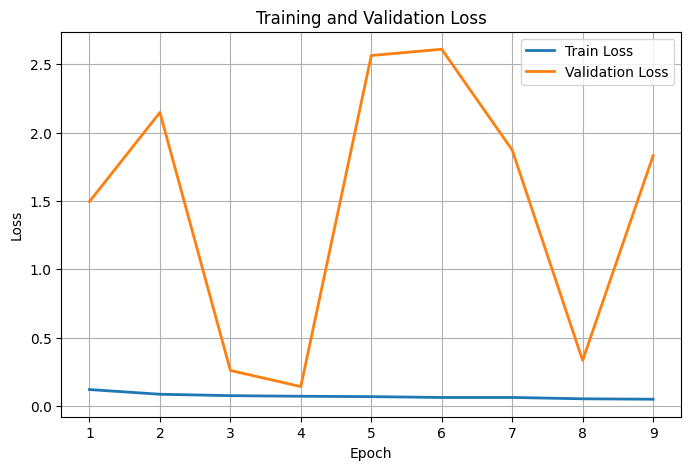

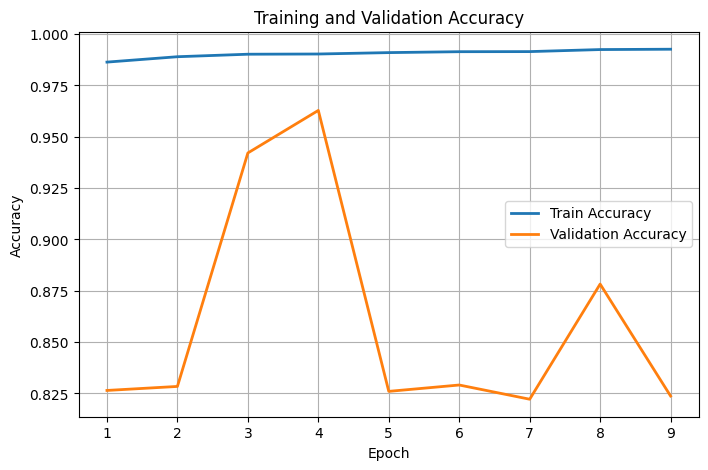

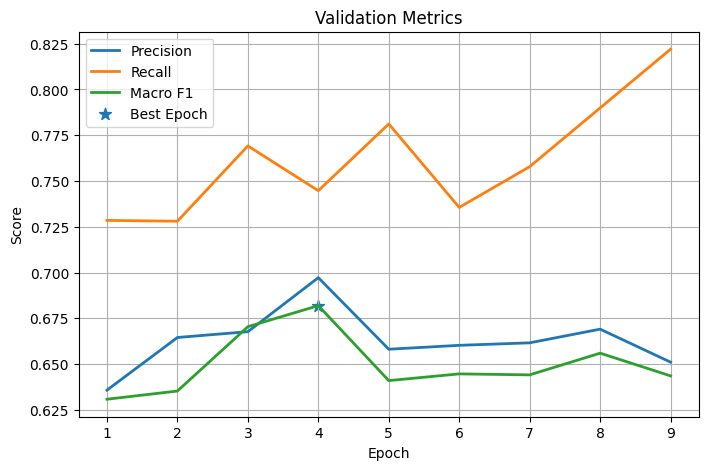


Best Epoch Summary


,Epoch,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Learning Rate
3,4.0,0.072,0.1429,0.9903,0.9628,0.6972,0.7447,0.6819,0.0003


In [32]:
# ============================================================
# Cell 19 - Training Curves
# ============================================================
print("=" * 70)
print("Plotting Training Curves...")
print("=" * 70)
import matplotlib.pyplot as plt
# ------------------------------------------------------------
# Loss Curve
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(history_df["Epoch"],history_df["Train Loss"],label="Train Loss",linewidth=2)
plt.plot(history_df["Epoch"],history_df["Validation Loss"],label="Validation Loss",linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True)
plt.legend()
plt.show()
# ------------------------------------------------------------
# Accuracy Curve
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(history_df["Epoch"],history_df["Train Accuracy"],label="Train Accuracy",linewidth=2)
plt.plot(history_df["Epoch"],history_df["Validation Accuracy"],label="Validation Accuracy",linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.grid(True)
plt.legend()
plt.show()
# -----------------------------------------------------------
# Validation Metrics
# -----------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(history_df["Epoch"],history_df["Validation Precision"],label="Precision",linewidth=2)
plt.plot(history_df["Epoch"],history_df["Validation Recall"],label="Recall",linewidth=2)
plt.plot(history_df["Epoch"],history_df["Validation F1"],label="Macro F1",linewidth=2)
best_epoch_row = history_df.loc[history_df["Validation F1"].idxmax()]
plt.scatter(best_epoch_row["Epoch"],best_epoch_row["Validation F1"],s=80,marker="*",label="Best Epoch")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.grid(True)
plt.legend()
plt.show()
print()
print("=" * 70)
print("Best Epoch Summary")
print("=" * 70)
display(best_epoch_row.to_frame().T.round(4))

In [33]:
# ============================================================
# Cell 20 - Save Results
# ============================================================
print("=" * 70)
print("Saving Evaluation Results...")
print("=" * 70)
import os
OUTPUT_DIR = "/kaggle/working"
# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------
classification_df.to_csv(os.path.join(OUTPUT_DIR,"classification_report.csv"))
# ------------------------------------------------------------
# Per-Class Metrics
# ------------------------------------------------------------
per_class_metrics.to_csv(os.path.join(OUTPUT_DIR,"per_class_metrics.csv"))
# ------------------------------------------------------------
# Confusion Matrices
# ------------------------------------------------------------
cm_df.to_csv(os.path.join(OUTPUT_DIR,"confusion_matrix.csv"))
cm_normalized_df.to_csv(os.path.join(OUTPUT_DIR,"normalized_confusion_matrix.csv"))
# ------------------------------------------------------------
# Training History
# ------------------------------------------------------------
if "history_df" in globals():
    history_df.to_csv(os.path.join(OUTPUT_DIR,"training_history.csv"),index=False)
# ------------------------------------------------------------
# Test Predictions
# ------------------------------------------------------------
prediction_df = pd.DataFrame({"True Label": all_labels,"Predicted Label": all_predictions})
prediction_df.to_csv(os.path.join(OUTPUT_DIR,"test_predictions.csv"),index=False)
# ------------------------------------------------------------
# Save Best Model
# ------------------------------------------------------------
torch.save(model.state_dict(),os.path.join(OUTPUT_DIR,"best_transformer_model.pth"))
# ------------------------------------------------------------
# Saved Files
# ------------------------------------------------------------
print()
print("=" * 70)
print("Files Saved")
print("=" * 70)
saved_files = ["classification_report.csv","per_class_metrics.csv","confusion_matrix.csv","normalized_confusion_matrix.csv","test_predictions.csv","best_transformer_model.pth"]
if "history_df" in globals():
    saved_files.append("training_history.csv")
for file in saved_files:
    print("✓", file)
print()
print(f"Location : {OUTPUT_DIR}")

Saving Evaluation Results...

Files Saved
✓ classification_report.csv
✓ per_class_metrics.csv
✓ confusion_matrix.csv
✓ normalized_confusion_matrix.csv
✓ test_predictions.csv
✓ best_transformer_model.pth
✓ training_history.csv

Location : /kaggle/working


In [34]:
# ============================================================
# Cell 21 - Final Experiment Summary
# ============================================================
print("=" * 70)
print("FINAL EXPERIMENT SUMMARY")
print("=" * 70)
print("Model                 : Temporal Transformer")
print("Dataset               : CSE-CIC-IDS2018")
print("Number of Classes     : 14")
print()
print("Window Size           : 32")
print("Stride                : 8")
print()
print(f"Training Windows      : {len(train_dataset):,}")
print(f"Validation Windows    : {len(val_dataset):,}")
print(f"Test Windows          : {len(test_dataset):,}")
print()
print(f"Best Epoch            : {best_epoch}")
print(f"Best Validation Macro F1 : {best_macro_f1:.4f}")
print()
print(f"Test Accuracy         : {test_accuracy:.4f}")
print(f"Test Macro Precision  : {test_precision:.4f}")
print(f"Test Macro Recall     : {test_recall:.4f}")
print(f"Test Macro F1         : {test_f1:.4f}")
print()
print("Saved Artifacts")
print("-" * 70)
saved_files = ["best_transformer_model.pth","classification_report.csv","per_class_metrics.csv","confusion_matrix.csv","normalized_confusion_matrix.csv","training_history.csv","test_predictions.csv"]
for file in saved_files:
    print(f"✓ {file}")
print()
print("=" * 70)
print("Experiment Completed Successfully")
print("=" * 70)

FINAL EXPERIMENT SUMMARY
Model                 : Temporal Transformer
Dataset               : CSE-CIC-IDS2018
Number of Classes     : 14

Window Size           : 32
Stride                : 8

Training Windows      : 1,376,362
Validation Windows    : 294,930
Test Windows          : 294,857

Best Epoch            : 4
Best Validation Macro F1 : 0.6819

Test Accuracy         : 0.9125
Test Macro Precision  : 0.7137
Test Macro Recall     : 0.7497
Test Macro F1         : 0.6979

Saved Artifacts
----------------------------------------------------------------------
✓ best_transformer_model.pth
✓ classification_report.csv
✓ per_class_metrics.csv
✓ confusion_matrix.csv
✓ normalized_confusion_matrix.csv
✓ training_history.csv
✓ test_predictions.csv

Experiment Completed Successfully
